# SRTY-3009 · Assignment 1 · Model Selection & Build


| Field | Details |
|---|---|
| **Course** | SRTY-3009 · Summer 2026 |
| **Assignment** | A1 Model Selection & Build |
| **Student 1** | Benjamin Morrison · 1279355 |
| **Student 2** | Logan Pukarowski · 1259868 |
| **Topic** | Psyops / Coordinated Inauthentic Behavior Detection |
| **Model** | TF-IDF + Logistic Regression (baseline) → RoBERTa-base (A2) |
| **Dataset** | FiveThirtyEight IRA Tweets + Kaggle Political Tweets |
| **Due** | Friday 15 May 2026 |

## Model Architecture

**Model:** LogisticRegression(max_iter=1000, class_weight='balanced', random_state=32)

**Input:** Raw tweet text (string) — 50,000 tweets total (25,000 verified IO from
FiveThirtyEight IRA dataset, 25,000 organic from Kaggle Political Tweets). After
TF-IDF vectorization: 10,000 numerical features per tweet representing word/bigram
importance scores.

**Preprocessing:** Remove URLs/mentions/hashtags/emojis → filter English only →
remove retweets → remove duplicates → balance classes (25,000 per class) →
TF-IDF vectorization (max_features=10000, ngram_range=(1,2), stop_words='english')
→ 80/20 stratified split

**Architecture:** TF-IDF converts each tweet into a 10,000-dimensional vector of
word importance scores → Logistic Regression learns a weight for each feature →
weighted sum passed through sigmoid function → outputs probability between 0 and 1
→ threshold 0.5 determines final class label

**Output:** Binary classification — 0 (Organic) or 1 (IO) + predict_proba()
confidence score between 0.0 and 1.0

**Loss:** Log loss (binary cross-entropy) — minimised by adjusting feature weights
to correctly separate IO from organic tweet vocabulary

**Metrics:** F1 Score (primary — equal weight on precision and recall, critical for
IO detection where missing a campaign is as costly as a false positive) ·
Precision/Recall per class · Confusion matrix · Accuracy (secondary — dataset is
balanced so accuracy is reliable here unlike imbalanced datasets)

**Platform:** Google Colab (free tier) · Python 3.11 · sklearn 1.6.1 ·
pandas 2.2.2 · numpy 1.26.4 · Training time: ~4 seconds on 40,000 rows

In [ ]:
# from google.colab import drive

# drive.mount('/content/drive')

In [ ]:
# Cell 1 - Imports & Environment Check
# Run this first to confirm all libraries are installed
# In A2 we will add: !pip install transformers torch

#pip install scikit-learn pandas matplotlib -q
# !pip install spacy
# !python -m spacy download en_core_web_lg
!pip install "flaml[automl]"
# import spacy
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn
import re
import time
from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from flaml import AutoML
from sklearn.datasets import fetch_california_housing

print('=' * 40)
print('LIBRARY VERSIONS')
print('=' * 40)
print(f"sklearn:    {sklearn.__version__}")
print(f"pandas:     {pd.__version__}")
print(f"numpy:      {np.__version__}")
print(f"matplotlib: {plt.matplotlib.__version__}")
print(f"re:         {re.__version__}")
print('=' * 40)
print("All libraries loaded OK")
print('=' * 40)

LIBRARY VERSIONS
sklearn:    1.6.1
pandas:     2.2.2
numpy:      2.0.2
matplotlib: 3.10.0
re:         2.2.1
All libraries loaded OK


In [ ]:
#Cell 2 - Loading and handling Dataset


df = pd.read_csv("/content/drive/MyDrive/datasets/english_sampled_tweets.csv")

df = df.drop_duplicates()
print(df.head())


# nlp = spacy.load('en_core_web_lg', enable=['ner'])


print(f"Dataset: {df.shape}")

# def normalize_entities(text, doc):
#     normalized = str(text)
#     for ent in reversed(doc.ents):
#         if ent.label_ == 'PERSON':
#             replacement = '[POLITICIAN]'
#         elif ent.label_ in ['GPE', 'LOC']:
#             replacement = '[LOCATION]'
#         elif ent.label_ == 'DATE':
#             replacement = '[DATE]'
#         elif ent.label_ == 'NORP':
#             replacement = '[POLITICAL_GROUP]'
#         elif ent.label_ == 'ORG':
#             replacement = '[ORGANIZATION]'
#         elif ent.label_ == 'EVENT':
#             replacement = '[EVENT]'
#         else:
#             continue
#         normalized = normalized[:ent.start_char] + replacement + normalized[ent.end_char:]

#     # Regex fallback for things NER missed
#     normalized = re.sub(r'\b(19|20)\d{2}\b', '[DATE]', normalized)
#     normalized = re.sub(r'\bobamacare\b', '[POLICY]', normalized, flags=re.IGNORECASE)
#     normalized = re.sub(r'\brealdonaldtrump\b', '[POLITICIAN]', normalized, flags=re.IGNORECASE)
#     normalized = re.sub(r'\bhedgebz\b', '', normalized, flags=re.IGNORECASE)
#     normalized = re.sub(r'\bamp\b', '', normalized, flags=re.IGNORECASE)
#     normalized = re.sub(r'\bcovid\b', '[EVENT]', normalized, flags=re.IGNORECASE)
#     normalized = re.sub(r'\bcovid-19\b', '[EVENT]', normalized, flags=re.IGNORECASE)
#     normalized = re.sub(r'\bcoronavirus\b', '[EVENT]', normalized, flags=re.IGNORECASE)
#     normalized = re.sub(r'\bfauci\b', '[POLITICIAN]', normalized, flags=re.IGNORECASE)
#     normalized = re.sub(r'\bomicron\b', '[EVENT]', normalized, flags=re.IGNORECASE)
#     normalized = re.sub(r'\s+', ' ', normalized).strip()
#     normalized = re.sub(r'^RT\s+@?\w*:?\s*', '', normalized, flags=re.IGNORECASE)

#     return normalized

# def normalize_batch(texts, batch_size=500):
#     normalized = []
#     texts = [str(t) for t in texts]
#     for i, doc in enumerate(nlp.pipe(texts, batch_size=batch_size)):
#         text = normalize_entities(texts[i], doc)
#         normalized.append(text)
#         if i % 5000 == 0:
#             print(f"  {i:,}/{len(texts):,} done")
#     return normalized

# print("Running NER...")
# start = time.time()
# df['text_normalized'] = normalize_batch(df['BoW'].tolist())  # ← fixed
# end = time.time()
# print(f"Done in {(end-start)/60:.1f} minutes")

# df.to_csv(r'C:\Users\morrb\PycharmProjectscleandatasets\cleaned_dataset_normalized.csv', index=False)
# print("Saved")

                                              userid           tweet_time  \
0  712a2ed4bfc7f6d5ff9af8ed3c5e5ad7f9246bf725f1e5...  2015-02-21 12:14:00   
1  0fbd30ccccb56a4e8e6b82a56d6e3dcd83a241c4256ec8...  2014-08-10 13:43:00   
2  9c886345764f23f0ad24c11f9fda913c0b7fa2cdb6bd7b...  2020-12-03 20:05:43   
3  c5bb0393c3e263f72a3785c7d85594413a919beabe33ca...  2020-12-04 08:12:27   
4  5a3d0b5bb669bae21e80542d4739c196ca4de3c0f1e174...  2020-12-03 03:40:20   

                                                 BoW  info_op  
0  ['looking', 'mirror', 'embarrassed', 'feel', '...        1  
1                               ['microsoft', 'ibm']        1  
2  ['ehh', 'dont', 'mind', 'new', 'itll', 'match'...        0  
3                   ['create', 'question', 'answer']        0  
4  ['far', 'lakers', 'announce', 'markieff', 'mor...        0  
Dataset: (149815, 4)


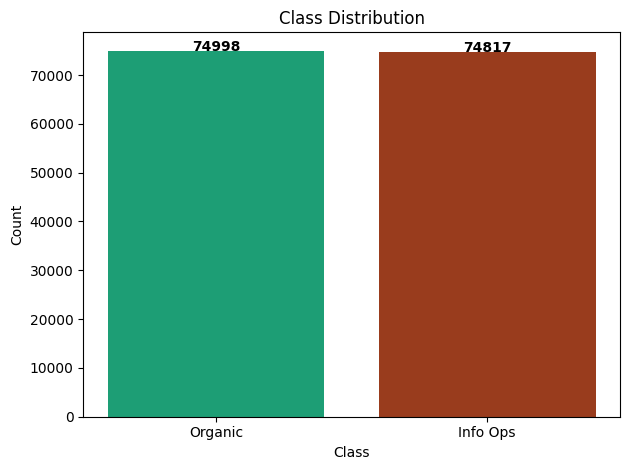

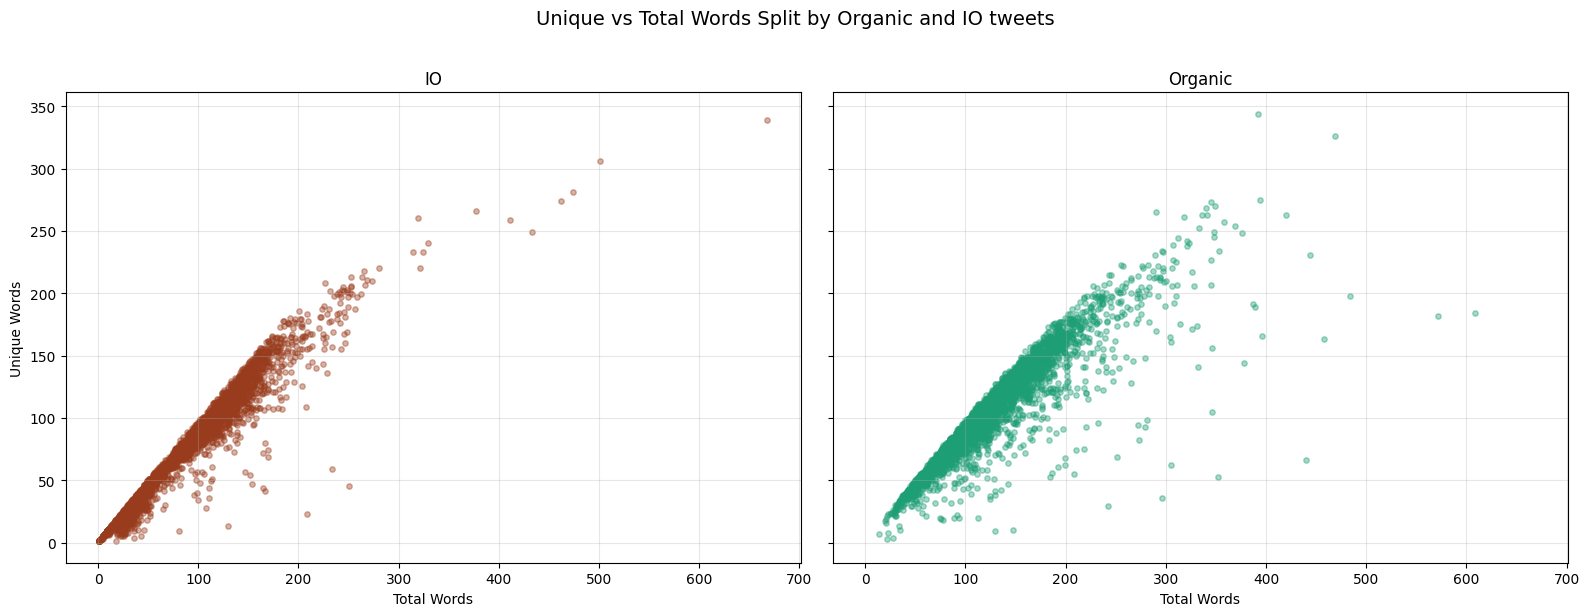

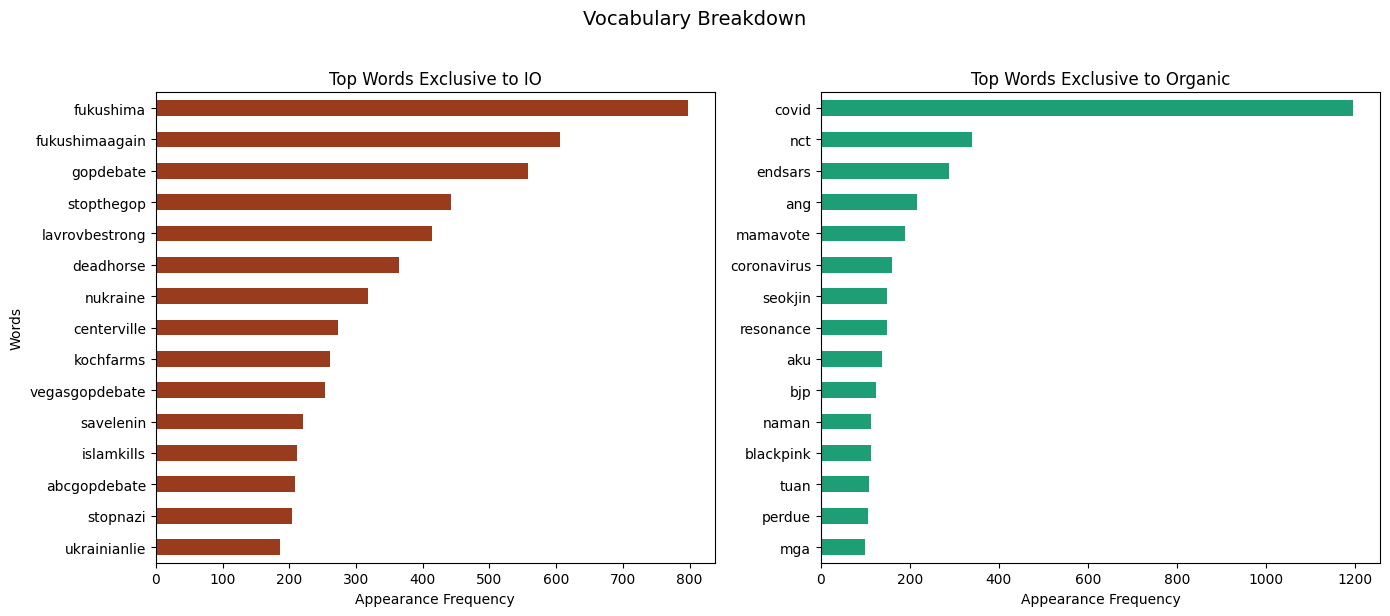

In [ ]:
#Cell 3 - Dataset details


#Total number of entries for both categories
counts = df['info_op'].value_counts()
plt.bar(['Organic', 'Info Ops'], counts.values, color=['#1D9E75', '#993C1D'])
plt.title('Class Distribution')
plt.xlabel('Class')
plt.ylabel('Count')
for i, count in enumerate(counts.values):
    plt.text(i, count + 0.1, str(count), ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

print(f'\n');

# Removing the array structure from the string
df['BoW_clean_list'] = (
    df['BoW']
    .str.strip("[]")
    .str.replace("'", "")
    .str.replace('"', '')
    .str.replace(r'\bquot;?\b', '', regex=True)
    .str.split(", ")
)

# Turning cleaned string into a DataFrame
df_wordlist = df.explode('BoW_clean_list')


df_wordlist = df_wordlist[df_wordlist['BoW_clean_list'] != '']
user_stats = df_wordlist.groupby(['userid', 'info_op'])['BoW_clean_list'].agg(
    Total_Words='size',
    Unique_Words='nunique'
).reset_index()

group_IO = user_stats[user_stats['info_op'] == 1]
group_organic = user_stats[user_stats['info_op'] == 0]

#Scatter plot showing the total words used per user versus total unique words used
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharex=True, sharey=True)

axes[0].scatter(
    group_IO['Total_Words'],
    group_IO['Unique_Words'],
    alpha=0.4, c='#993C1D', s=15
)
axes[0].set_title('IO')
axes[0].set_xlabel('Total Words')
axes[0].set_ylabel('Unique Words')
axes[0].grid(True, alpha=0.3)

axes[1].scatter(
    group_organic['Total_Words'],
    group_organic['Unique_Words'],
    alpha=0.4, c='#1D9E75', s=15
)
axes[1].set_title('Organic')
axes[1].set_xlabel('Total Words')
axes[1].grid(True, alpha=0.3)

plt.suptitle('Unique vs Total Words Split by Organic and IO tweets', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

print(f'\n')


word_counts = df_wordlist.groupby(['info_op', 'BoW_clean_list']).size().unstack(fill_value=0).T

unique_io = word_counts[(word_counts[1] > 0) & (word_counts[0] == 0)][1]

unique_organic = word_counts[(word_counts[0] > 0) & (word_counts[1] == 0)][0]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Words found only in IO posts
top_io = unique_io.sort_values(ascending=True).tail(15)
top_io.plot(kind='barh', ax=axes[0], color='#993C1D')
axes[0].set_title('Top Words Exclusive to IO')
axes[0].set_xlabel('Appearance Frequency')
axes[0].set_ylabel('Words')

# Words found only in Organic posts
top_organic = unique_organic.sort_values(ascending=True).tail(15)
top_organic.plot(kind='barh', ax=axes[1], color='#1D9E75')
axes[1].set_title('Top Words Exclusive to Organic')
axes[1].set_xlabel('Appearance Frequency')
axes[1].set_ylabel('')

plt.suptitle('Vocabulary Breakdown', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
#Cell 4 - TF-IDF vectorization


#instiatiate the TFIDF vectorizer
vectorizer = TfidfVectorizer(max_features=50000, ngram_range=(1,2), stop_words='english')

#transforms x into a list of vectors based on the text field of the dataset
x = vectorizer.fit_transform(df['BoW'])

#makes y the vector of true labels for text to compare
y = df['info_op']

#create the different sets for training and testing the model
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2, random_state=32, stratify=y)


In [ ]:
#cell 5 - logistic regression


#instanatiate the logistic regression with the training parameters
lr = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=32)

#train the model and track how long it took to display
start = time.time()
lr.fit(x_train, y_train)
end = time.time()

print(f"training completed in {end-start:.2f} seconds")



training completed in 6.73 seconds


              precision    recall  f1-score   support

     Organic       0.81      0.84      0.83     15000
          IO       0.83      0.81      0.82     14963

    accuracy                           0.82     29963
   macro avg       0.82      0.82      0.82     29963
weighted avg       0.82      0.82      0.82     29963



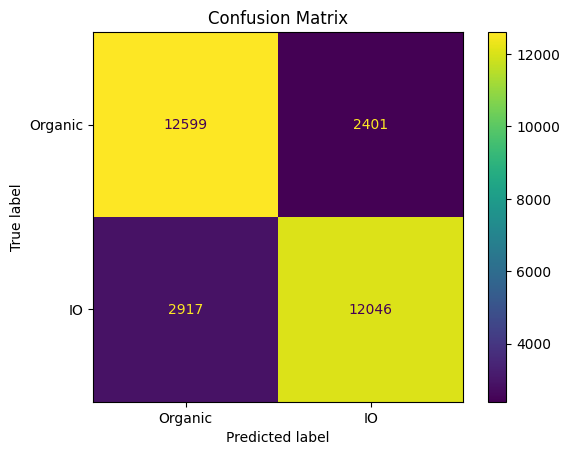

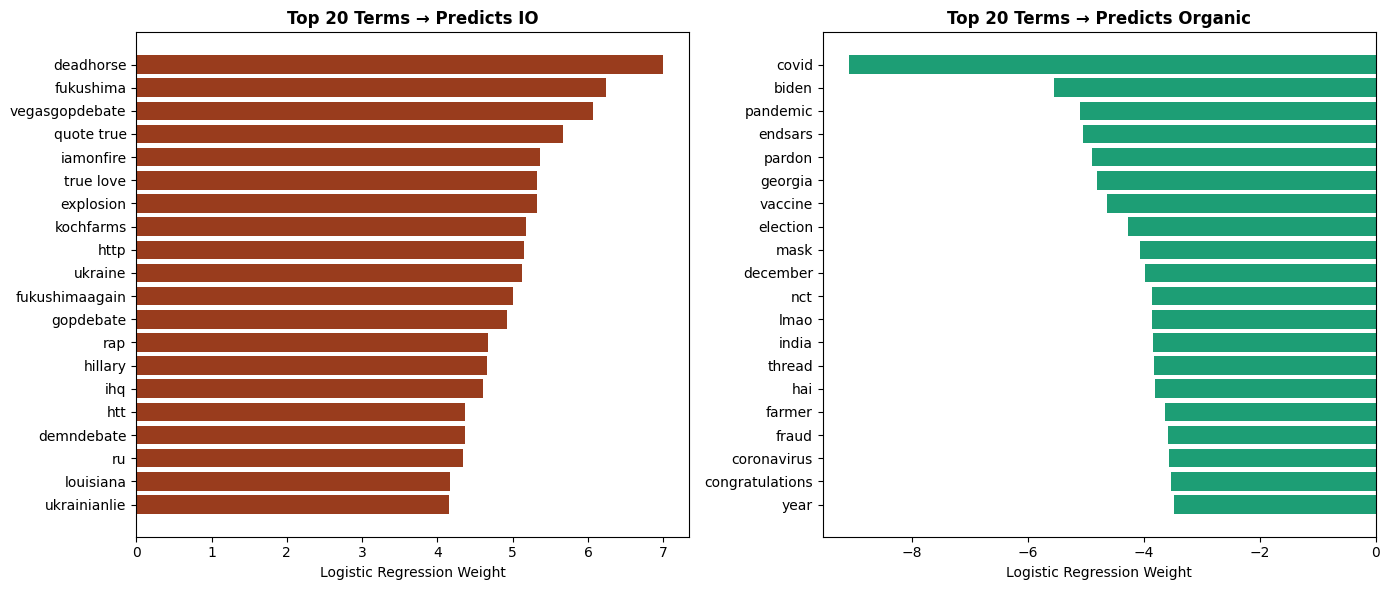

In [ ]:
# Cell 6 - Evaluate & print metrics


#tests the model for the accuracy
y_pred = lr.predict(x_test);

#prints the classificatin report showing the precision, recall, f1 score of the model
print(classification_report(y_test, y_pred, target_names=['Organic', 'IO']))

# Calculate the confusion matrix

cm = confusion_matrix(y_test, y_pred, labels=lr.classes_)

# Use the calculated cm and the model's classes_ attribute
disp = ConfusionMatrixDisplay(confusion_matrix=cm,  display_labels=['Organic', 'IO'])
disp.plot()
plt.title('Confusion Matrix')
plt.show()


# Get feature names and their learned weights
feature_names = vectorizer.get_feature_names_out()
weights = lr.coef_[0]  # one weight per feature

# Create a dataframe of feature → weight
coef_df = pd.DataFrame({
    'term': feature_names,
    'weight': weights
}).sort_values('weight', ascending=False)

# Top 20 most IO-predictive terms
top_io = coef_df.head(20)
# Top 20 most organic-predictive terms
top_organic = coef_df.tail(20).sort_values('weight')

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# IO terms
axes[0].barh(top_io['term'], top_io['weight'], color='#993C1D')
axes[0].set_title('Top 20 Terms → Predicts IO', fontweight='bold')
axes[0].set_xlabel('Logistic Regression Weight')
axes[0].invert_yaxis()

# Organic terms
axes[1].barh(top_organic['term'], top_organic['weight'], color='#1D9E75')
axes[1].set_title('Top 20 Terms → Predicts Organic', fontweight='bold')
axes[1].set_xlabel('Logistic Regression Weight')
axes[1].invert_yaxis()


plt.tight_layout()
plt.show()


In [ ]:


# Initialize an AutoML instance
automl = AutoML()
# Specify automl goal and constraint
automl_settings = {
    "time_budget": 15,  # in seconds
    "metric": "accuracy",
    "task": "classification",
    "log_file_name": "iris.log",
}
# Train with labeled input data
automl.fit(X_train=x_train, y_train=y_train, **automl_settings)
# Predict
print(automl.predict_proba(x_train))
# Print the best model
print(automl.model.estimator)

[flaml.automl.logger: 05-15 13:43:34] {2375} INFO - task = classification
[flaml.automl.logger: 05-15 13:43:34] {2386} INFO - Evaluation method: holdout
[flaml.automl.logger: 05-15 13:43:34] {2489} INFO - Minimizing error metric: 1-accuracy
[flaml.automl.logger: 05-15 13:43:34] {2606} INFO - List of ML learners in AutoML Run: ['lgbm', 'rf', 'xgboost', 'extra_tree', 'xgb_limitdepth', 'sgd', 'lrl1']
[flaml.automl.logger: 05-15 13:43:34] {2911} INFO - iteration 0, current learner lgbm
[flaml.automl.logger: 05-15 13:43:35] {3046} INFO - Estimated sufficient time budget=111089s. Estimated necessary time budget=2572s.
[flaml.automl.logger: 05-15 13:43:35] {3097} INFO -  at 1.4s,	estimator lgbm's best error=4.8607e-01,	best estimator lgbm's best error=4.8607e-01
[flaml.automl.logger: 05-15 13:43:35] {2911} INFO - iteration 1, current learner lgbm


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[flaml.automl.logger: 05-15 13:43:36] {3097} INFO -  at 2.6s,	estimator lgbm's best error=4.7347e-01,	best estimator lgbm's best error=4.7347e-01
[flaml.automl.logger: 05-15 13:43:36] {2911} INFO - iteration 2, current learner sgd


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
INFO:flaml.tune.searcher.blendsearch:No low-cost partial config given to the search algorithm. For cost-frugal search, consider providing low-cost values for cost-related hps via 'low_cost_partial_config'. More info can be found at https://microsoft.github.io/FLAML/docs/FAQ#about-low_cost_partial_config-in-tune


[flaml.automl.logger: 05-15 13:43:37] {3097} INFO -  at 3.2s,	estimator sgd's best error=3.0144e-01,	best estimator sgd's best error=3.0144e-01
[flaml.automl.logger: 05-15 13:43:37] {2911} INFO - iteration 3, current learner sgd
[flaml.automl.logger: 05-15 13:43:37] {3097} INFO -  at 3.5s,	estimator sgd's best error=3.0144e-01,	best estimator sgd's best error=3.0144e-01
[flaml.automl.logger: 05-15 13:43:37] {2911} INFO - iteration 4, current learner lgbm
[flaml.automl.logger: 05-15 13:43:38] {3097} INFO -  at 4.5s,	estimator lgbm's best error=4.7347e-01,	best estimator sgd's best error=3.0144e-01
[flaml.automl.logger: 05-15 13:43:38] {2911} INFO - iteration 5, current learner sgd


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[flaml.automl.logger: 05-15 13:43:38] {3097} INFO -  at 4.9s,	estimator sgd's best error=2.6097e-01,	best estimator sgd's best error=2.6097e-01
[flaml.automl.logger: 05-15 13:43:38] {2911} INFO - iteration 6, current learner sgd
[flaml.automl.logger: 05-15 13:43:41] {3097} INFO -  at 7.8s,	estimator sgd's best error=2.4353e-01,	best estimator sgd's best error=2.4353e-01
[flaml.automl.logger: 05-15 13:43:41] {2911} INFO - iteration 7, current learner xgboost
[flaml.automl.logger: 05-15 13:43:42] {3097} INFO -  at 8.3s,	estimator xgboost's best error=4.8198e-01,	best estimator sgd's best error=2.4353e-01
[flaml.automl.logger: 05-15 13:43:42] {2911} INFO - iteration 8, current learner xgboost
[flaml.automl.logger: 05-15 13:43:42] {3097} INFO -  at 8.6s,	estimator xgboost's best error=4.8198e-01,	best estimator sgd's best error=2.4353e-01
[flaml.automl.logger: 05-15 13:43:42] {2911} INFO - iteration 9, current learner xgboost
[flaml.automl.logger: 05-15 13:43:42] {3097} INFO -  at 8.9s,	es